In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score



In [8]:
# import pandas as pd
# from scipy.stats import mannwhitneyu

# # Cargar el dataframe
# df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)

# # Filtrar los grupos de relapse y cured
# relapse = df[df['group_name'] == 1]
# cured = df[df['group_name'] == 0]

# # Lista de columnas que representan las características (excluyendo 'group_name' u otras columnas no numéricas)
# feature_columns = [col for col in df.columns if col != 'group_name']  # Asegúrate de excluir la columna 'group_name'

# # Diccionario para almacenar los resultados
# results = {}

# # Aplicar el test de Mann-Whitney U a cada característica
# for feature in feature_columns:
#     stat, p_value = mannwhitneyu(relapse[feature], cured[feature])
#     results[feature] = {'statistic': stat, 'p_value': p_value}

# # Convertir los resultados en un DataFrame para mostrar
# results_df = pd.DataFrame(results).T

# # Mostrar los resultados
# print(results_df)

# # Comprobar cuáles características son estadísticamente significativas
# significant_features = results_df[results_df['p_value'] < 0.05]
# print("\nCaracterísticas estadísticamente significativas (p < 0.05):")
# print(significant_features)




In [9]:
import pandas as pd
from pingouin import multivariate_normality
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
from pingouin import multivariate_normality

# Cargar tu dataset (simulación)
df = pd.read_csv("csvs/datos_allcases_classweights_lagfeatures_after_reducing_var_corr.csv")

# 1️⃣ Seleccionar solo las columnas numéricas (sin ID ni fechas)
df_numeric = df.drop(columns=["m_id", "day_of_study"])  

# 2️⃣ Imputar NaN con la media (puedes cambiar a mediana si hay outliers)
imputer = SimpleImputer(strategy="mean")
df_imputed = imputer.fit_transform(df_numeric)

# 3️⃣ Escalar con StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)
from sklearn.decomposition import PCA
pca = PCA(n_components=10)  # Reducir a 10 componentes
df_pca = pca.fit_transform(df_scaled)

# 4️⃣ Aplicar test de normalidad multivariante
test = multivariate_normality(df_pca, alpha=0.05)
print(test)



HZResults(hz=3.044351103897895, pval=0.0, normal=False)


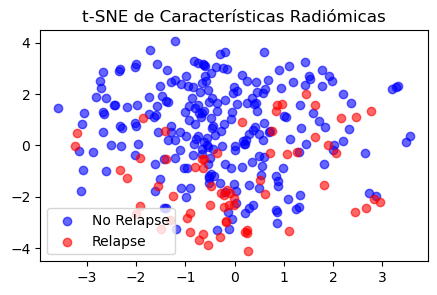

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# 📌 Cargar datos
X = pd.read_csv("data_to_use.csv")

# 🎯 Extraer etiquetas y eliminar del dataset antes de t-SNE
y = X['group_name']  # Ya es 0 o 1
X = X.drop(columns=['group_name'])  # Quitar la columna de etiquetas

# 📌 0. Comprobar si hay NaN y eliminarlos (o imputarlos)
simple_imputer = SimpleImputer(strategy='mean')
X_imputed = simple_imputer.fit_transform(X)

# 📌 1. Normalización de las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# # 📌 2. Filtrar características con varianza baja (evita ruido)
# selector = VarianceThreshold(threshold=0.01)  # Filtra columnas con varianza muy baja
# X_filtered = selector.fit_transform(X_scaled)

# 📌 3. Reducir la dimensión con PCA antes de t-SNE
# pca = PCA(30)  # Se reduce a 30 dimensiones antes de t-SNE
# X_pca = pca.fit_transform(X_filtered)

# 📌 4. Aplicar t-SNE
X_embedded = TSNE(n_components=2, perplexity=100, random_state=42).fit_transform(X_scaled)

# 📊 5. Graficar los resultados
plt.figure(figsize=(5, 3))
plt.scatter(X_embedded[y == 0, 0], X_embedded[y == 0, 1], c='blue', label='No Relapse', alpha=0.6)
plt.scatter(X_embedded[y == 1, 0], X_embedded[y == 1, 1], c='red', label='Relapse', alpha=0.6)
plt.title("t-SNE de Características Radiómicas")
plt.legend()
plt.show()



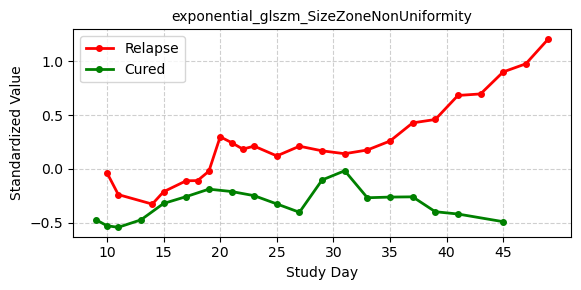

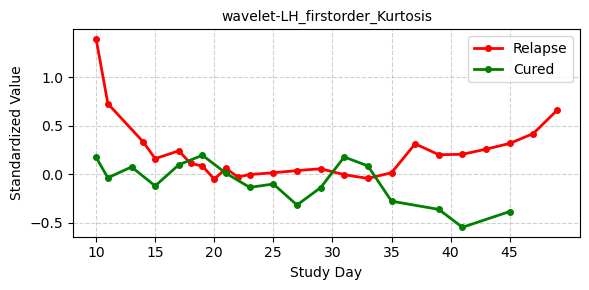

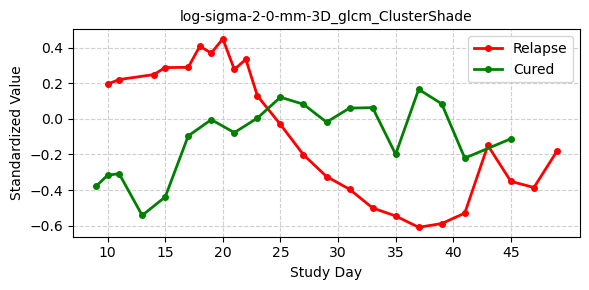

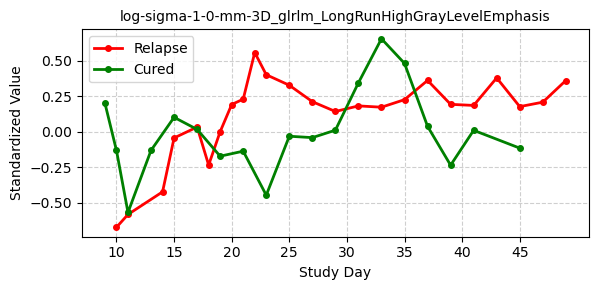

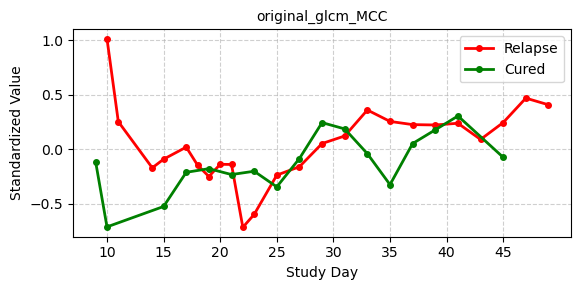

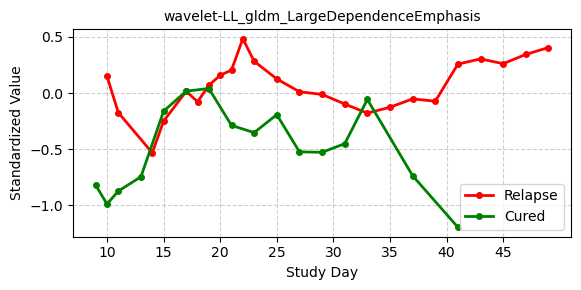

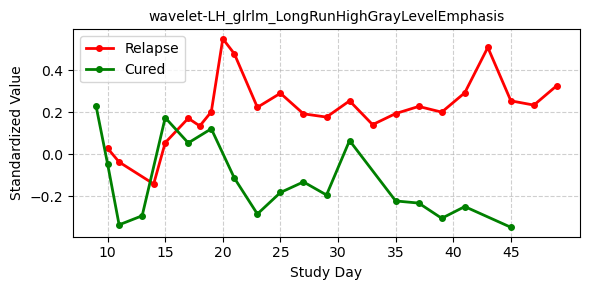

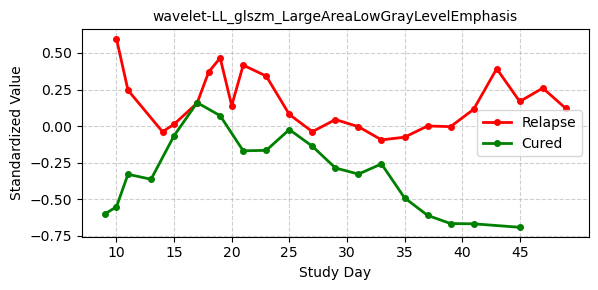

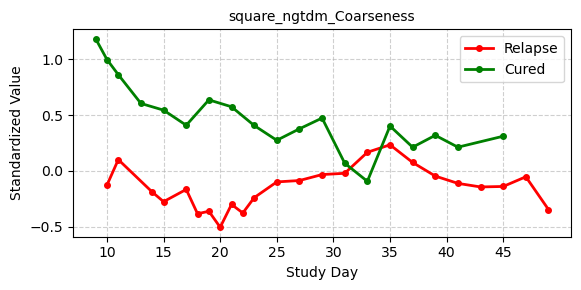

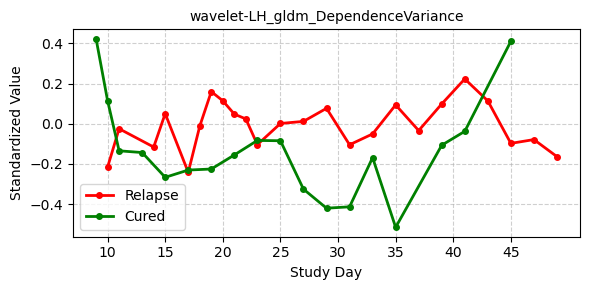

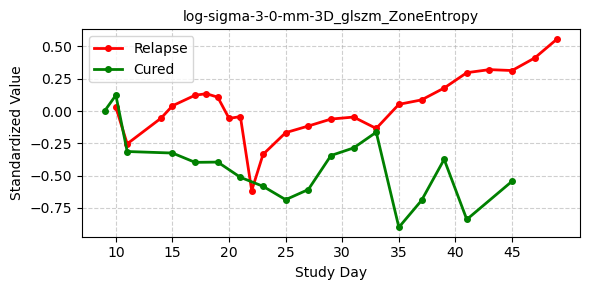

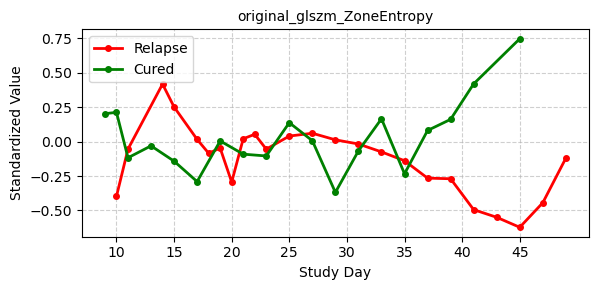

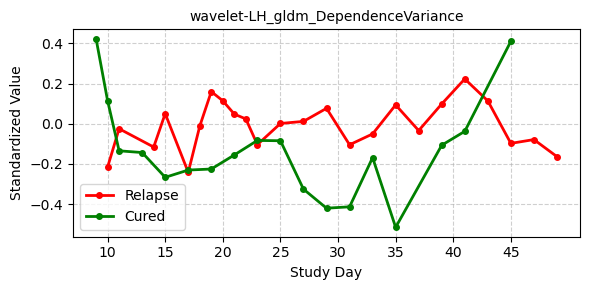

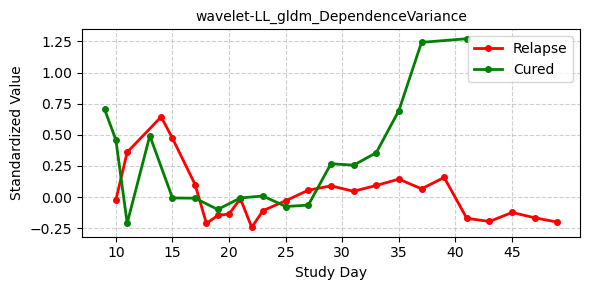

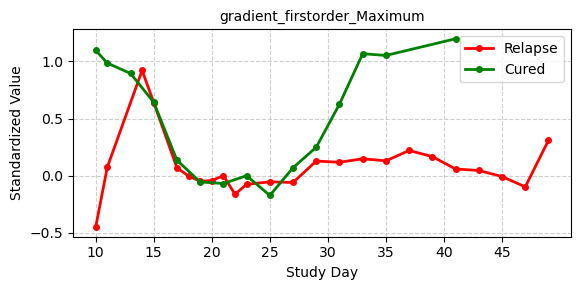

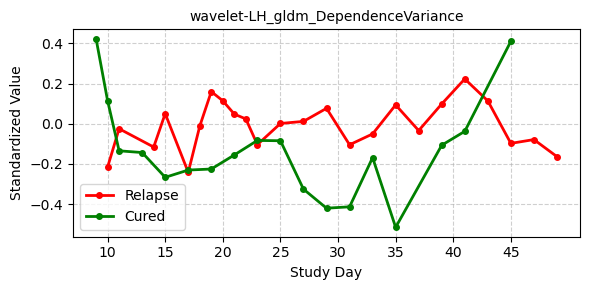

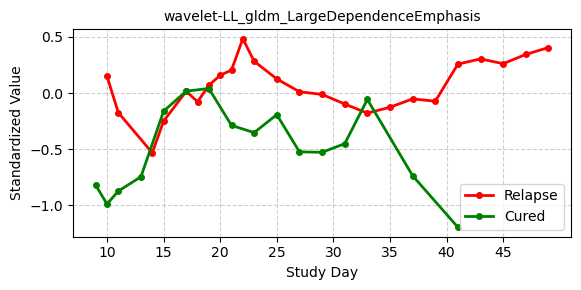

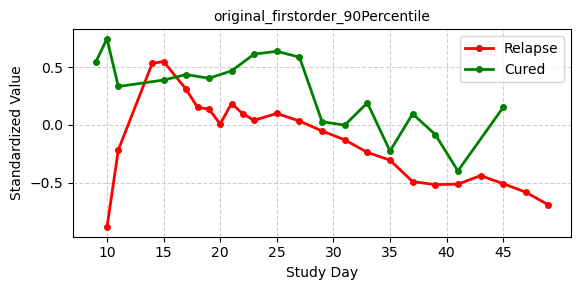

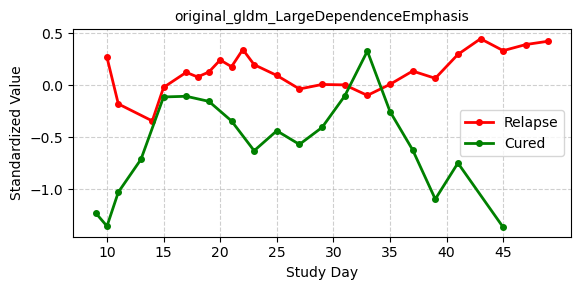

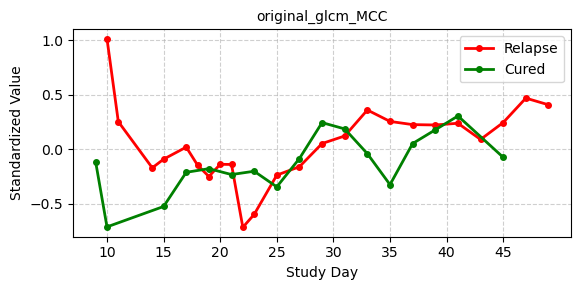

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from src.processing import Processing

# Cargar datos
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NEW, all_features=False)
dataclass.read()
df = dataclass.df

# Filtrar ratones problemáticos
df = df[~df["m_id"].isin([1258, 1260, 1261, 1297, 1299, 1359, 1360, 1361])]

# Features por fold (ya sin "slope"/"rolling_mean")
features_per_fold = {
    0: [
        "exponential_glszm_SizeZoneNonUniformity",
        "wavelet-LH_firstorder_Kurtosis",
        "log-sigma-2-0-mm-3D_glcm_ClusterShade",
        "log-sigma-1-0-mm-3D_glrlm_LongRunHighGrayLevelEmphasis",
        "original_glcm_MCC",
        "wavelet-LL_gldm_LargeDependenceEmphasis",
        "wavelet-LH_glrlm_LongRunHighGrayLevelEmphasis",
        "wavelet-LL_glszm_LargeAreaLowGrayLevelEmphasis",
        "square_ngtdm_Coarseness",
        "wavelet-LH_gldm_DependenceVariance"
    ],
    1: [
        "log-sigma-3-0-mm-3D_glszm_ZoneEntropy",
        "original_glszm_ZoneEntropy",
        "wavelet-LH_gldm_DependenceVariance",
        "wavelet-LL_gldm_DependenceVariance",
        "gradient_firstorder_Maximum",
        "wavelet-LH_gldm_DependenceVariance",
        "wavelet-LL_gldm_LargeDependenceEmphasis",
        "original_firstorder_90Percentile",
        "original_gldm_LargeDependenceEmphasis",
        "original_glcm_MCC"
    ]
}

# Escalar todas las features involucradas
all_features = set(f for features in features_per_fold.values() for f in features)
scaler = RobustScaler()
df[list(all_features)] = scaler.fit_transform(df[list(all_features)])

# Colores por grupo
colors = {1: 'green', 0: 'red'}

# Crear un plot individual por feature
for fold, features in features_per_fold.items():
    for feature in features:
        plt.figure(figsize=(6, 3))

        # Filtrar outliers
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

        # Agrupar y suavizar
        df_grouped = df_clean.groupby(["group_name", "day_of_study"])[feature].agg(['mean']).reset_index()
        df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

        # Graficar por grupo
        for group in df_grouped["group_name"].unique():
            subset = df_grouped[df_grouped["group_name"] == group]
            if group == 1:
                label = "Cured"
            else:
                label = "Relapse"
            plt.plot(subset["day_of_study"], subset["smoothed_mean"], '-o',
                     linewidth=2, markersize=4, color=colors[group], label=f"{label}")

        plt.xlabel("Study Day")
        plt.ylabel("Standardized Value")
        plt.title(f"{feature}", fontsize=10)
        plt.xticks(np.arange(10, df["day_of_study"].max() + 1, 5))
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()  # O usa plt.savefig(f"output_final/hyp1/imgs/fold_{fold}_{feature}.png")


In [12]:
import os
import pandas as pd

import numpy as np

def resumen_dias(dias_str):
    dias = [int(d) for d in dias_str.strip("[]").split() if d.isdigit()]
    if len(dias) == 0:
        return "-"
    dias = sorted(dias)
    return f"{min(dias)}–{max(dias)}"


# Ruta base donde están los folds
base_path = "output_final/hyp1/baseline/expanding_window_split"
NUM_FOLDS = 10  # o los que tengas


# Lista para almacenar cada fila como diccionario
rows = []

# Iterar sobre cada fold
for i in range(NUM_FOLDS):
    metrics_path = os.path.join(base_path, f"fold_{i}", "metrics.csv")
    if os.path.exists(metrics_path):
        try:
            df = pd.read_csv(metrics_path)
            row = df.loc[0].to_dict()

            # Calcular Specificity si se puede
            tn, fp = row["true_negatives"], row["false_positives"]
            specificity = tn / (tn + fp) if (tn + fp) > 0 else None

            rows.append({
                "Fold": i,
                "Train Days (min–max)": resumen_dias(row["days_of_study_in_train"]),
                "Test Days (min–max)": resumen_dias(row["days_of_study_in_test"]),
                "Accuracy": round(row["accuracy"], 4),
                "F1-macro": round(row["f1_macro"], 4),
                "F1-weighted": round(row["f1_weighted"], 4),
                "Recall (Sensitivity)": round(row["recall"], 4),
                "Specificity": round(specificity, 4) if specificity is not None else None,
                "ROC AUC": round(row["roc_auc"], 4),
                "Precision": round(row["precision"], 4),
                "TP": row["true_positives"],
                "TN": row["true_negatives"],
                "FP": row["false_positives"],
                "FN": row["false_negatives"],
            })

        except Exception as e:
            print(f"Error en fold {i}: {e}")
    else:
        print(f"Fold {i} no encontrado.")

# Crear DataFrame resumen
results_df = pd.DataFrame(rows)

# Mostrar
print(results_df)

# (Opcional) Exportar a CSV o LaTeX
results_df.to_csv("tabla_metrics_folds.csv", index=False)
# print(results_df.to_latex(index=False))  # para Overleaf


   Fold Train Days (min–max) Test Days (min–max)  Accuracy  F1-macro  \
0     0                 9–15               15–17    0.8519    0.8224   
1     1                 9–17               17–21    0.8148    0.7970   
2     2                 9–21               21–23    0.7037    0.6447   
3     3                 9–23               23–25    0.6667    0.6137   
4     4                 9–25               25–27    0.8148    0.8052   
5     5                 9–27               27–31    0.7778    0.6318   
6     6                 9–31               31–33    0.8148    0.4490   
7     7                 9–33               35–37    0.9259    0.7300   
8     8                 9–37               37–41    0.9630    0.9179   
9     9                 9–41               41–49    1.0000    1.0000   

   F1-weighted  Recall (Sensitivity)  Specificity  ROC AUC  Precision  TP  TN  \
0       0.8411                0.6000       1.0000   0.8412     1.0000   6  17   
1       0.8170                0.7778       0.

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Crear carpeta de salida si no existe
output_dir = "output_final/hyp1/imgs"
os.makedirs(output_dir, exist_ok=True)

# Datos por fold
data = [
    {"Fold": 0, "TP": 6, "TN": 17, "FP": 0, "FN": 4},
    {"Fold": 1, "TP": 7, "TN": 15, "FP": 3, "FN": 2},
    {"Fold": 2, "TP": 4, "TN": 15, "FP": 4, "FN": 4},
    {"Fold": 3, "TP": 4, "TN": 14, "FP": 5, "FN": 4},
    {"Fold": 4, "TP": 8, "TN": 14, "FP": 4, "FN": 1},
    {"Fold": 5, "TP": 2, "TN": 19, "FP": 3, "FN": 3},
    {"Fold": 6, "TP": 0, "TN": 22, "FP": 2, "FN": 3},
    {"Fold": 7, "TP": 1, "TN": 24, "FP": 2, "FN": 0},
    {"Fold": 8, "TP": 3, "TN": 23, "FP": 1, "FN": 0},
    {"Fold": 9, "TP": 1, "TN": 26, "FP": 0, "FN": 0},
]

# Dibujar matriz sin colores
def plot_bw_conf_matrix(tp, tn, fp, fn, fold):
    conf_mat = np.array([[tp, fn], [fp, tn]])
    labels = ["Positive", "Negative"]

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Fold {fold}", fontsize=10)

    # Dibujar cada celda a mano
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(conf_mat[i, j]),
                    va='center', ha='center', fontsize=12)

            # Dibujar borde negro
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 fill=False, color='black', linewidth=1.2)
            ax.add_patch(rect)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_aspect('equal')
    plt.tight_layout()

    # Guardar imagen
    output_path = os.path.join(output_dir, f"conf_matrix_fold_{fold}.png")
    plt.savefig(output_path, dpi=300)
    plt.close()

# Generar y guardar todas
for row in data:
    plot_bw_conf_matrix(row["TP"], row["TN"], row["FP"], row["FN"], row["Fold"])



Fold 6: Recall no definido, se omite.


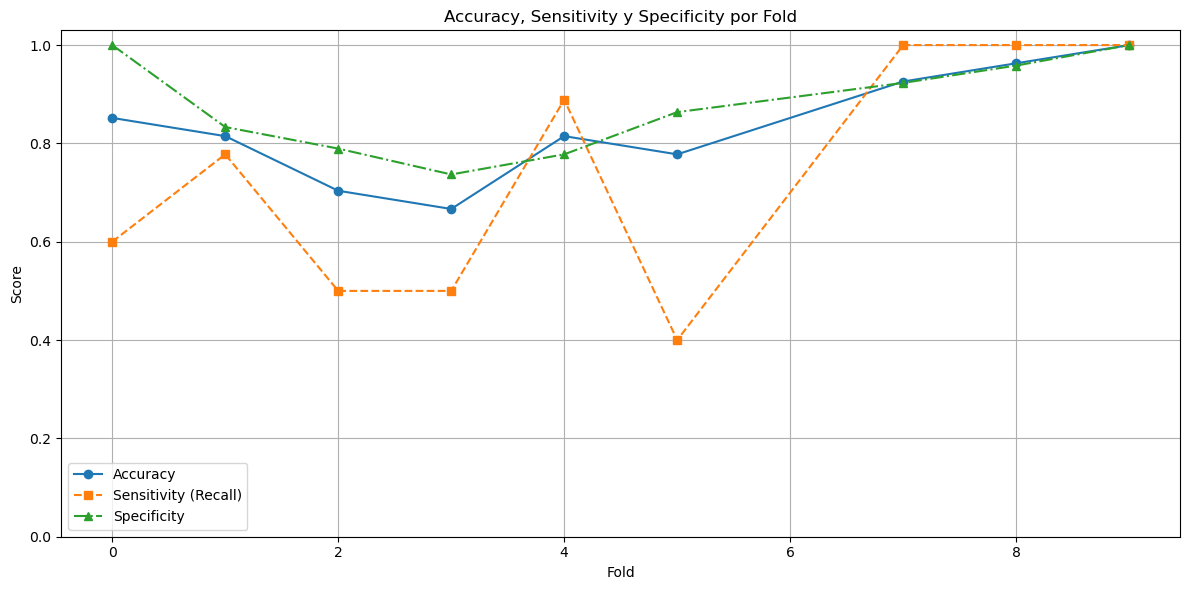

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ruta base donde están los folds
base_path = "output_final/hyp1/baseline/expanding_window_split"

# Listas para guardar resultados
folds = []
accuracies = []
sensitivities = []
specificities = []
roc_auc = []

# Iterar sobre los folders
for i in range(10):  # Ajusta según el total de folds
    metrics_path = os.path.join(base_path, f"fold_{i}", "metrics.csv")
    if os.path.exists(metrics_path):
        df = pd.read_csv(metrics_path)
        try:
            acc = df.loc[0, "accuracy"]
            recall = df.loc[0, "recall"]
            tn = df.loc[0, "true_negatives"]
            fp = df.loc[0, "false_positives"]
            auc_roc = df.loc[0, "roc_auc"]

            # Verificamos que se puedan calcular correctamente
            if pd.isna(recall) or recall == 0:
                print(f"Fold {i}: Recall no definido, se omite.")
                continue

            if (tn + fp) == 0 or tn == 0:
                print(f"Fold {i}: No hay negativos, no se puede calcular especificidad. Se omite.")
                continue

            specificity = tn / (tn + fp)

            # Agregamos resultados
            folds.append(i)
            accuracies.append(acc)
            sensitivities.append(recall)
            specificities.append(specificity)
            roc_auc.append(auc_roc)

        except Exception as e:
            print(f"Error en fold {i}: {e}")
            continue
    else:
        print(f"No encontrado: {metrics_path}")

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(folds, accuracies, marker='o', linestyle='-', label="Accuracy")
plt.plot(folds, sensitivities, marker='s', linestyle='--', label="Sensitivity (Recall)")
plt.plot(folds, specificities, marker='^', linestyle='-.', label="Specificity")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Accuracy, Sensitivity y Specificity por Fold")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## 0-Baseline All Features

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_all_features/grouped_combinations_split_with_sampling"
NUM_FOLDS = 16
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')



# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score Macro: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count             well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [7, 14, 18, 20, 22, 24, 24, 24]                    1                [7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [8, 8, 10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [14, 16, 16, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 18]

===== Fold 3 =====
 m_id_1263  true_label  well_predicted_count                                      

## 1-Baseline All Features Oversampling

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_all_features_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 16
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count                well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     9 [7, 7, 14, 18, 20, 22, 24, 24, 24]                  0.0                 []

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [8, 8, 10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                      well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    18 [14, 16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    1               [10]

===== Fold 3 =====
 m_id_1263  true_label  well_predicted_count                        

## 2-Baseline All Features Oversampling No Control Cases

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)
f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                              well_predicted_days  bad_predicted_count                                                               bad_predicted_days
      1263           0                    36 [14, 17, 19, 19, 19, 21, 23, 23, 25, 27, 27, 29, 29, 31, 33, 35, 37, 37, 37, 39, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47, 47]                   20 [11, 11, 11, 14, 14, 17, 17, 21, 21, 23, 23, 25, 25, 25, 29, 31, 31, 33, 33, 35]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                          well_predicted_days  bad_predicted_count               bad_predicted_days
      1264           0                    35 [11, 11, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 23, 23, 23, 25, 25, 27, 29, 29, 29, 31

## 3-Var HC Features Oversampling No Control Cases

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                                  well_predicted_days  bad_predicted_count                                           bad_predicted_days
      1263           0                    41 [14, 14, 17, 19, 19, 19, 21, 21, 21, 23, 23, 25, 25, 27, 27, 29, 29, 31, 31, 33, 33, 35, 37, 37, 39, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47, 47]                   15 [11, 11, 11, 14, 17, 17, 23, 23, 25, 25, 29, 31, 33, 35, 37]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                              well_predicted_days  bad_predicted_count                           bad_predicted_days
      1264           0                    32 [11, 11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 23, 23, 25, 25, 27, 29, 29, 29, 31

## 4-Var HC SF Features Oversampling No Control Cases

In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_sf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')




===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                                  well_predicted_days  bad_predicted_count                                           bad_predicted_days
      1263           0                    41 [14, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 25, 27, 27, 29, 29, 31, 31, 33, 33, 35, 37, 37, 37, 39, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47, 47]                   15 [11, 11, 11, 14, 14, 17, 23, 23, 25, 25, 25, 29, 31, 33, 35]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                              well_predicted_days  bad_predicted_count           bad_predicted_days
      1264           0                    36 [11, 11, 11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 25, 25, 27, 27, 29

## 5-LF Var HC SF Features Oversampling No Control Cases

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_lf_sf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                                                  well_predicted_days  bad_predicted_count                           bad_predicted_days
      1263           0                    45 [14, 14, 14, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 23, 27, 27, 29, 29, 29, 31, 31, 31, 33, 35, 35, 37, 37, 37, 39, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47, 47]                   11 [11, 11, 11, 17, 17, 25, 25, 25, 25, 33, 33]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                                  well_predicted_days  bad_predicted_count       bad_predicted_days
      1264           0                    37 [15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 25, 25, 25, 27, 27, 29, 29, 29

## 6-Heuristic LF Var HC SF Features Oversampling No Control Cases

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_heuristic_lf_sf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count              well_predicted_days  bad_predicted_count                                   bad_predicted_days
      1276           1                     8 [19, 23, 25, 25, 27, 27, 37, 39]                   13 [11, 15, 17, 17, 19, 23, 29, 31, 33, 33, 35, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    12 [10, 13, 15, 17, 17, 19, 19, 21, 21, 23, 23, 27]                  0.0                 []

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count          well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     7 [10, 13, 17, 19, 21, 23, 27]                    1               [15]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                   

## 7-Heuristic LF Var HC NOSF Features Oversampling No Control Cases

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_heuristic_lf_NOsf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')



===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count          well_predicted_days  bad_predicted_count                                       bad_predicted_days
      1276           1                     7 [17, 23, 23, 25, 27, 27, 41]                   14 [11, 15, 17, 19, 19, 25, 29, 31, 33, 33, 35, 37, 39, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                      well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    10 [10, 13, 15, 17, 19, 21, 21, 23, 23, 27]                    2           [17, 19]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count          well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     7 [13, 15, 17, 19, 21, 23, 27]                    1               [10]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                          bad_predi

## 8-Heuristic LF Var HC NOSF Features Oversampling No Control Cases again HEURISTIC

In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_heuristic_lf_NOsf_var_hc_oversample_reduce_again_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count              well_predicted_days  bad_predicted_count                                   bad_predicted_days
      1276           1                     8 [17, 17, 19, 23, 25, 25, 27, 37]                   13 [11, 15, 19, 23, 27, 29, 31, 33, 33, 35, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    12 [10, 13, 15, 17, 17, 19, 19, 21, 21, 23, 23, 27]                  0.0                 []

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count          well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     7 [10, 13, 15, 19, 21, 23, 27]                    1               [17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                   

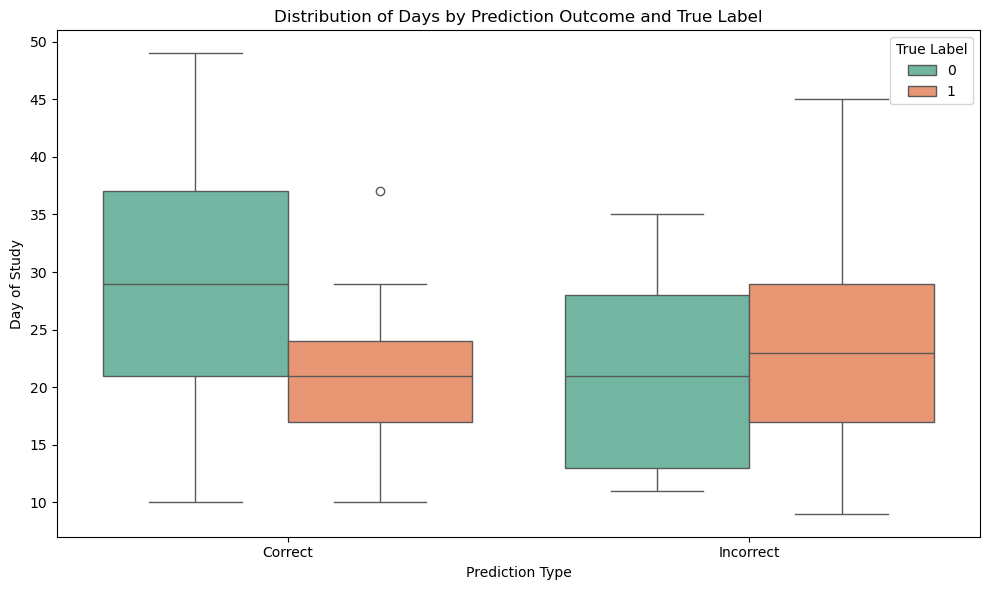

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, x="Prediction", y="Day", hue="True Label", palette="Set2")

    plt.title("Distribution of Days by Prediction Outcome and True Label")
    plt.xlabel("Prediction Type")
    plt.ylabel("Day of Study")
    plt.legend(title="True Label")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)


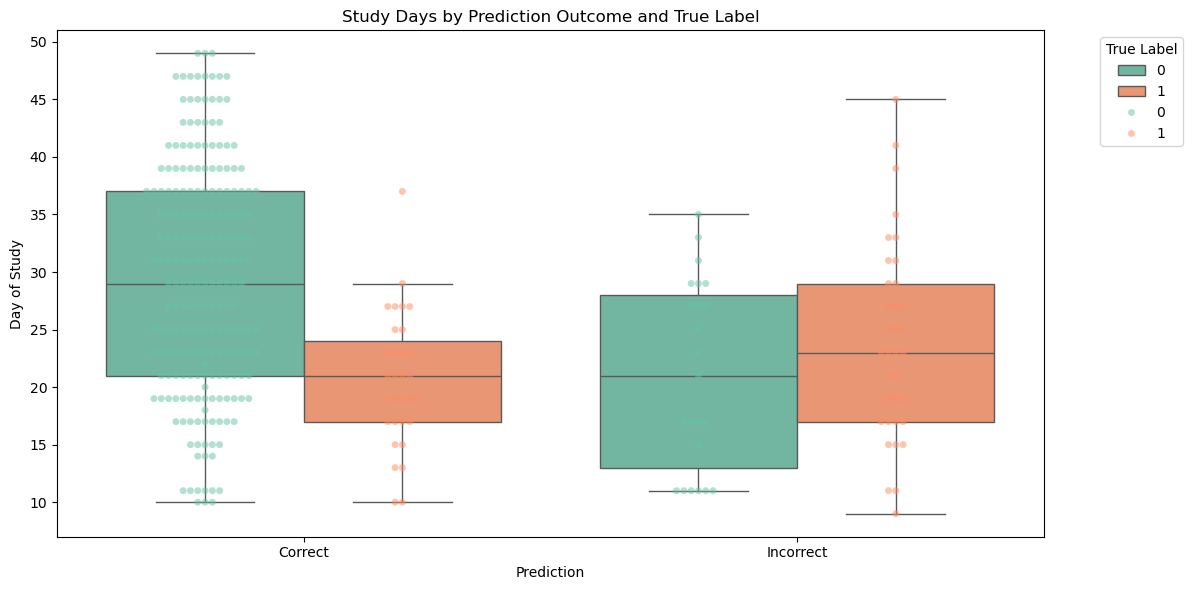

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x="Prediction", y="Day", hue="True Label", palette="Set2", fliersize=0)
    sns.swarmplot(data=df_plot, x="Prediction", y="Day", hue="True Label", dodge=True, palette="Set2", alpha=0.5)
    plt.title("Study Days by Prediction Outcome and True Label")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

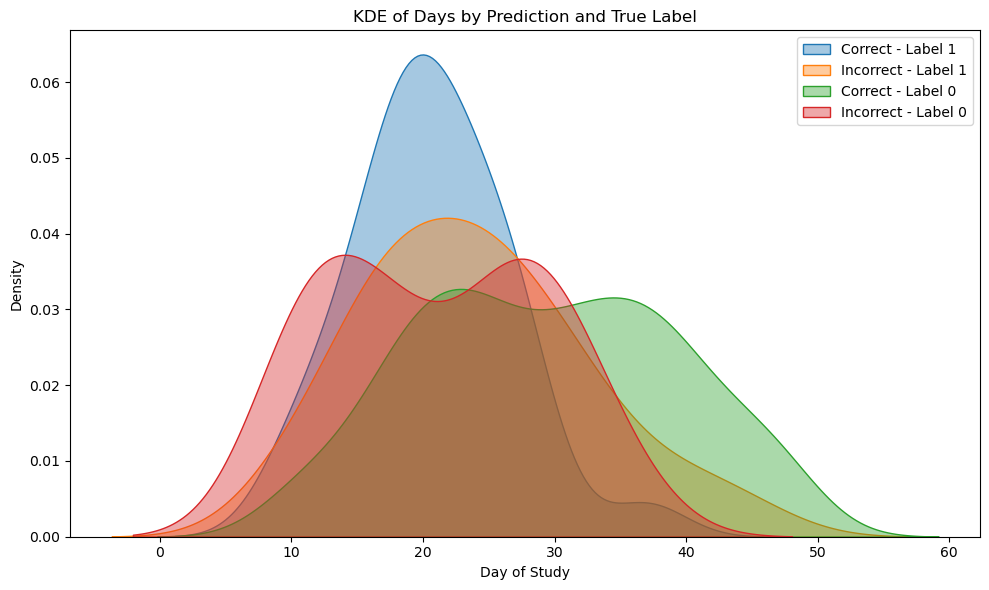

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    for label in df_plot["True Label"].unique():
        for pred_type in ["Correct", "Incorrect"]:
            subset = df_plot[(df_plot["True Label"] == label) & (df_plot["Prediction"] == pred_type)]
            sns.kdeplot(subset["Day"], label=f"{pred_type} - Label {label}", fill=True, alpha=0.4)

    plt.title("KDE of Days by Prediction and True Label")
    plt.xlabel("Day of Study")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

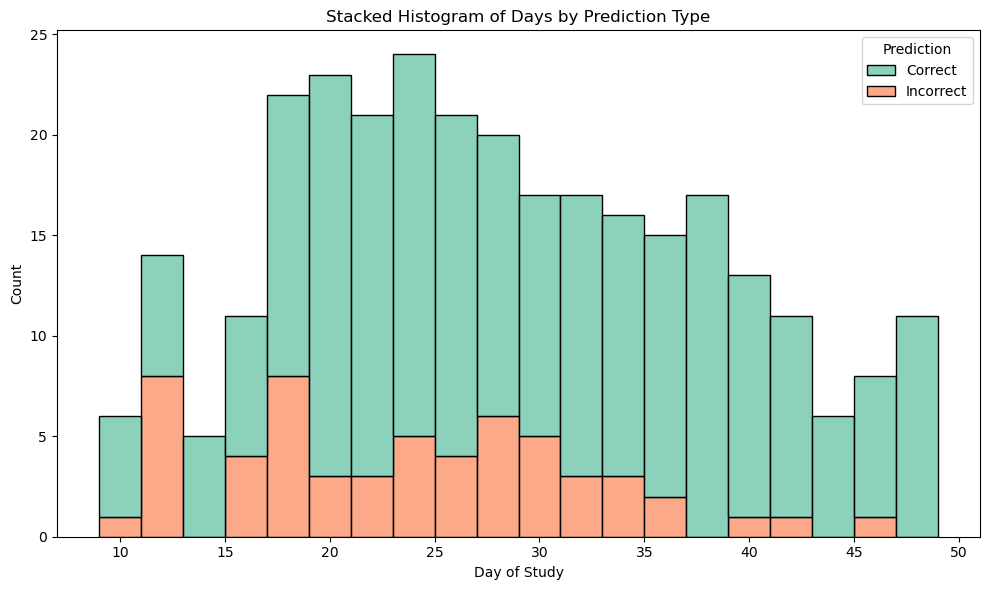

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_plot, x="Day", hue="Prediction", multiple="stack", bins=20, palette="Set2")
    plt.title("Stacked Histogram of Days by Prediction Type")
    plt.xlabel("Day of Study")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

### 9-Heuristic LF Var HC NOSF Features UnderSampling No Control Cases again HEURISTIC

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/baseline_no_control_heuristic_lf_NOsf_var_hc_undersample_reduce_again_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                                   bad_predicted_days
      1276           1                     4    [19, 25, 27, 27]                   17 [11, 15, 17, 17, 19, 23, 23, 25, 29, 31, 33, 33, 35, 37, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    11 [10, 13, 15, 17, 17, 19, 21, 21, 23, 23, 27]                    1               [19]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count          well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     7 [10, 13, 15, 19, 21, 23, 27]                    1               [17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                     

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/RF_baseline_no_control_heuristic_lf_NOsf_var_hc_oversample_reduce_again_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count              well_predicted_days  bad_predicted_count                                   bad_predicted_days
      1276           1                     8 [17, 17, 19, 23, 23, 25, 27, 37]                   13 [11, 15, 19, 25, 27, 29, 31, 33, 33, 35, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    12 [10, 13, 15, 17, 17, 19, 19, 21, 21, 23, 23, 27]                  0.0                 []

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count              well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     8 [10, 13, 15, 17, 19, 21, 23, 27]                  0.0                 []

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                           

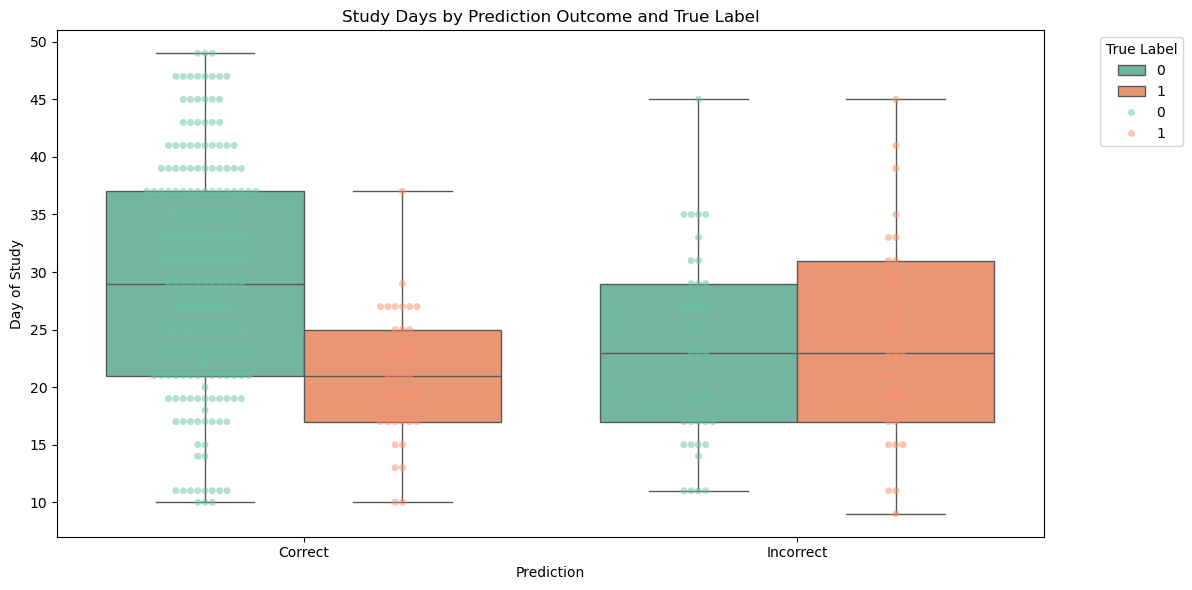

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x="Prediction", y="Day", hue="True Label", palette="Set2", fliersize=0)
    sns.swarmplot(data=df_plot, x="Prediction", y="Day", hue="True Label", dodge=True, palette="Set2", alpha=0.5)
    plt.title("Study Days by Prediction Outcome and True Label")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final/hyp3/RF/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')



===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count      well_predicted_days  bad_predicted_count                                           bad_predicted_days
      1276           1                     6 [17, 17, 23, 25, 25, 27]                   15 [11, 15, 19, 19, 23, 27, 29, 31, 33, 33, 35, 37, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     8 [17, 17, 19, 21, 21, 23, 23, 27]                    4   [10, 13, 15, 19]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count  well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     5 [10, 19, 21, 23, 27]                    3       [13, 15, 17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                              bad_predicted_days
      1285        

In [32]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 16
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')



In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output11111/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1360  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1360           0                    11 [18, 18, 18, 20, 20, 20, 20, 22, 22, 22, 22]                    4   [11, 14, 16, 16]

===== Fold 1 =====
 m_id_1276  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count                       bad_predicted_days
      1276           1                    11 [15, 17, 23, 23, 25, 25, 27, 27, 29, 35, 37]                   10 [11, 17, 19, 19, 31, 33, 33, 39, 41, 45]

===== Fold 2 =====
 m_id_1281  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    11 [10, 13, 15, 17, 19, 19, 21, 21, 23, 23, 27]                    1               [17]

===== Fold 3 =====
 m_id_1284  true_label  well_predicted_count well_predicted_days  bad_predicted_count bad_predic

In [34]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "outputbest/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 10
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [35]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_nocontrol_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 10
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_nocontrol_lagfeatures_heuristic_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                                   bad_predicted_days
      1276           1                     4    [25, 25, 27, 35]                   17 [11, 15, 17, 17, 19, 19, 23, 23, 27, 29, 31, 33, 33, 37, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    11 [10, 13, 15, 17, 19, 19, 21, 21, 23, 23, 27]                    1               [17]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count      well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     6 [13, 15, 19, 21, 23, 27]                    2           [10, 17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                          bad

In [37]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [38]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr_new/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')
# from sklearn.metrics import average_precision_score

# pr_auc = average_precision_score(y_true_all, y_pred_all)

# # Mostrar PR AUC
# print(f'PR AUC: {pr_auc:.4f}')

In [39]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 10
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [40]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/new/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [41]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_classweights_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [42]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allfeatures/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')


In [43]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')
